## 0. PHÁT BIỂU BÀI TOÁN
- Phân tích dữ liệu nhằm khảo sát tính khả thi cho việc xây dựng mô hình dự đoán lượng CO2 phát thải trong năm của 1 nước dựa trên các biến đặc trưng sau:
    + coal-lignite (Lượng than đá tiêu thụ trong năm)
    + electricity (Lượng điện tiêu thụ trong năm)
    + natural-gas (Lượng khí gas tiêu thụ trong năm)
    + oil-products (Lượng sản phẩm từ dầu tiêu thụ trong năm)
    + renewables (Phần trăm điện năng được tạo ra bằng năng lượng tái tạo trong năm)
    + renewables-wind-solar (Phần trăm điện năng được tạo ra bằng năng lượng tái tạo gió và mặt trời trong năm)
    + total-energy (Tổng năng lượng tiêu thụ trong năm)
- Vì biến mục tiêu Y (Lượng phát thải CO2) là một biến số thực nên việc mô hình hóa này thuộc bài toán Hồi quy (Regression).
- Bài toán được đặt ra là khả thi (về dữ liệu) để xây dựng mô hình dự đoán, dựa trên các cơ sở sau:
    + Dữ liệu có kích thước 1681 mẫu và 7 đặc trưng, đủ lớn để thực hiện các thuật toán Hồi quy mà không bị hiện tượng overfitting do thiếu mẫu
    + Chất lượng dữ liệu được đảm bảo: Các vấn đề về giá trị NaN, Outliers đã được xử lý tại bước làm sạch dữ liệu,
    + Lượng thông tin dự báo tốt: Phân tích ma trận tương quan (Pearson/Spearman) cho thấy có một số biến đặc trưng (như X1, X2...) có hệ số tương quan tuyến tính rõ rệt với biến mục tiêu Y. Điều này chứng tỏ đặc trưng mang tín hiệu dự đoán tốt (Được chứng minh tại mục 5. Mối quan hệ giữa các biến dữ liệu)
- Tập đặc trưng hữu ích có thể dùng để xây dựng mô hình là: 
    + coal-lignite 
    + electricity 
    + natural-gas
    + oil-products
    + total-energy

## 1. THU THẬP DỮ LIỆU
- Nguồn dữ liệu: https://yearbook.enerdata.net
- Dữ liệu thu thập bao gồm 8 loại năng lượng tiêu thụ của 48 quốc gia từ năm 1990-2024
    + coal-lignite (Lượng than đá tiêu thụ trong năm) : (https://yearbook.enerdata.net/coal-lignite/coal-world-consumption-data.html)
    + electricity (Lượng điện tiêu thụ trong năm) : (https://yearbook.enerdata.net/electricity/electricity-domestic-consumption-data.html)
    + natural-gas (Lượng khí gas tiêu thụ trong năm) : (https://yearbook.enerdata.net/natural-gas/gas-consumption-data.html)
    + oil-products (Lượng sản phẩm từ dầu tiêu thụ trong năm) : (https://yearbook.enerdata.net/oil-products/world-oil-domestic-consumption-statistics.html)
    + renewables (Phần trăm điện năng được tạo ra bằng năng lượng tái tạo trong năm) : (https://yearbook.enerdata.net/renewables/renewable-in-electricity-production-share.html)
    + renewables-wind-solar (Phần trăm điện năng được tạo ra bằng năng lượng tái tạo gió và mặt trời trong năm) : (https://yearbook.enerdata.net/renewables/wind-solar-share-electricity-production.html)
    + total-energy (Tổng năng lượng tiêu thụ trong năm) : (https://yearbook.enerdata.net/total-energy/world-consumption-statistics.html)
    + co2-emissions: Lượng CO2 phát thải trong năm (https://yearbook.enerdata.net/co2/emissions-co2-data-from-fuel-combustion.html)
- Trang web cung cấp API có dạng: https://api-yearbook.enerdata.net/values?fullCode%5B0%5D={full_code}&zoneCode%5B0%5D={zone_code}&pagination=false&locale=en (Mở F12 nhấn Tab Networks rồi nhấn từng trang dữ liệu muốn xem sẽ phát hiện được API của trang cung cấp)
    + full_code là mã code để truy cập đến trang nhiên liệu tương ứng
    + zone_code là mã quốc gia 
- Các bước thực hiện đã được làm ở file full_data_crawler.ipynb
- Dữ liệu thô sau khi thu thập được lưu ở: raw data/raw_data.jsonl

### Xuất ra một số thông tin về tập dữ liệu thu được:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder


In [3]:
data_file_path = 'processed/processed_data.csv'
data_frame = pd.read_csv(data_file_path)

In [4]:
data_table = data_frame.pivot_table(index=['Country', 'Year'],columns='Type',values='Value')
unit = data_frame[['Type', 'Unit']].drop_duplicates().set_index('Type').to_dict()['Unit']
type_data = data_table.columns.get_level_values(0).drop_duplicates().to_list()
country = data_table.index.get_level_values(0).drop_duplicates().to_list()

In [5]:
unit

{'total-energy': 'Mtep',
 'coal-lignite': 'Mt',
 'oil-products': 'Mt',
 'natural-gas': 'Gm3',
 'electricity': 'TWh',
 'renewables': '%',
 'renewables-wind-solar': '%',
 'co2-emissions': 'MtCO2'}

In [6]:
type_data

['co2-emissions',
 'coal-lignite',
 'electricity',
 'natural-gas',
 'oil-products',
 'renewables',
 'renewables-wind-solar',
 'total-energy']

In [7]:
data_table.to_csv("clean_data.csv",index=True)
df = pd.read_csv('clean_data.csv')
df

,Country,Year,co2-emissions,coal-lignite,electricity,natural-gas,oil-products,renewables,renewables-wind-solar,total-energy
0,Algeria,1990,50.118890,1.065000,12.555000,14.602868,8.072359,0.838301,0.000000,21.166734
1,Algeria,1991,53.221121,1.042000,12.868000,15.804842,8.484124,1.689248,0.000000,23.165670
2,Algeria,1992,55.906245,0.975000,13.962000,16.234184,9.088171,1.088264,0.000000,24.170773
3,Algeria,1993,58.585925,0.779000,13.905000,18.928921,8.416735,1.818182,0.000000,26.026684
4,Algeria,1994,57.655106,0.882000,14.251000,19.120842,7.718124,0.834674,0.000000,27.025515
...,...,...,...,...,...,...,...,...,...,...
1675,Vietnam,2020,306.554358,101.963268,215.743000,8.970158,21.062792,35.557388,4.327714,101.219157
1676,Vietnam,2021,288.652757,99.313080,223.528557,7.601025,18.933276,44.127725,12.282918,103.412281
1677,Vietnam,2022,289.006827,95.222535,225.448181,8.299373,26.092425,49.089093,12.836926,105.792257
1678,Vietnam,2023,341.059719,118.013299,235.159827,7.670531,26.988333,39.986927,12.716901,115.765929


### Xuất ra các thống kê mô tả trực quan về dữ liệu đơn biến đối với một vài biến quan trọng

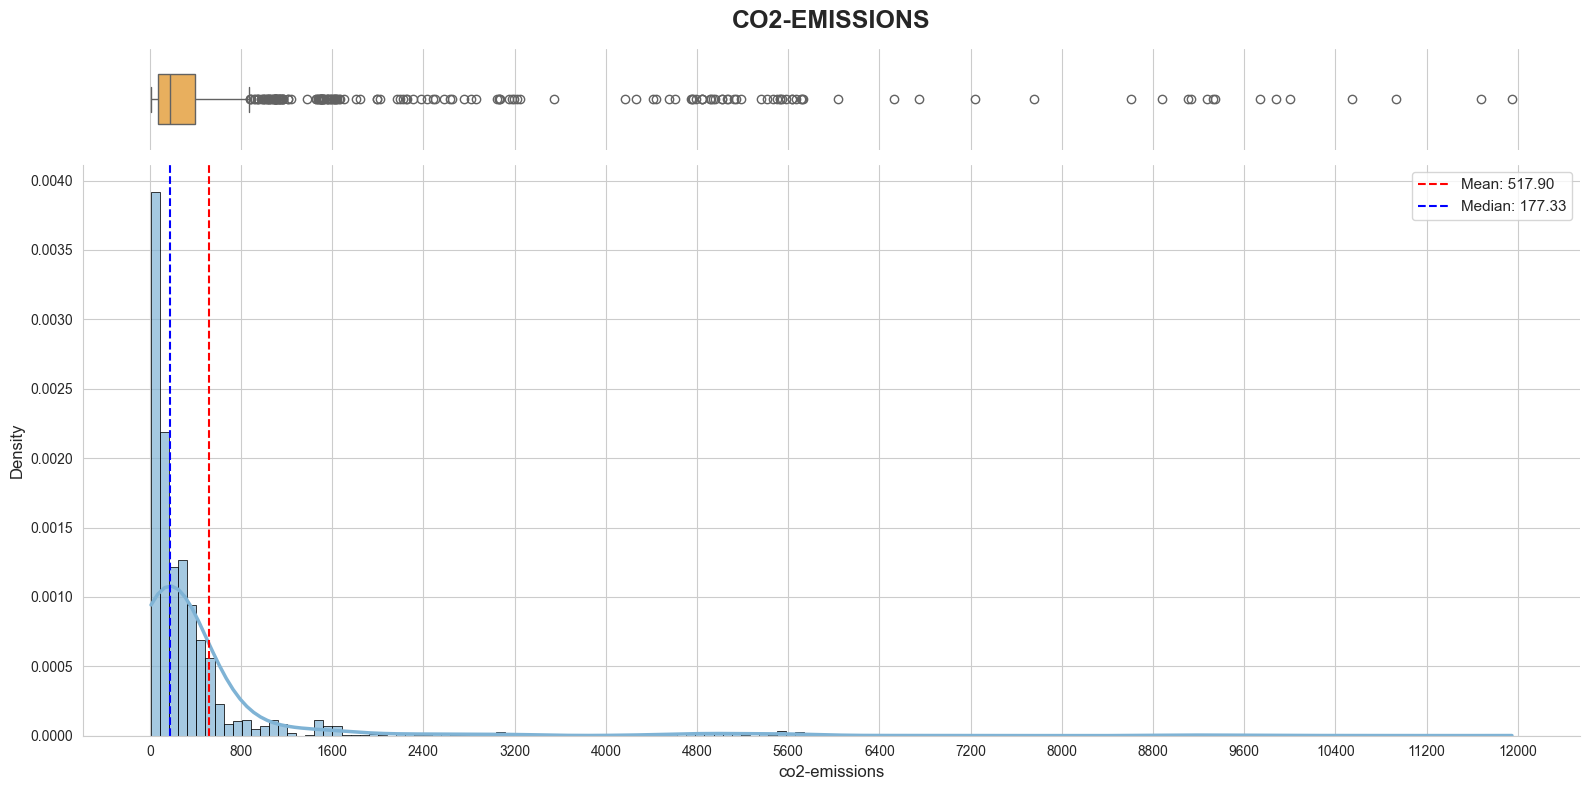

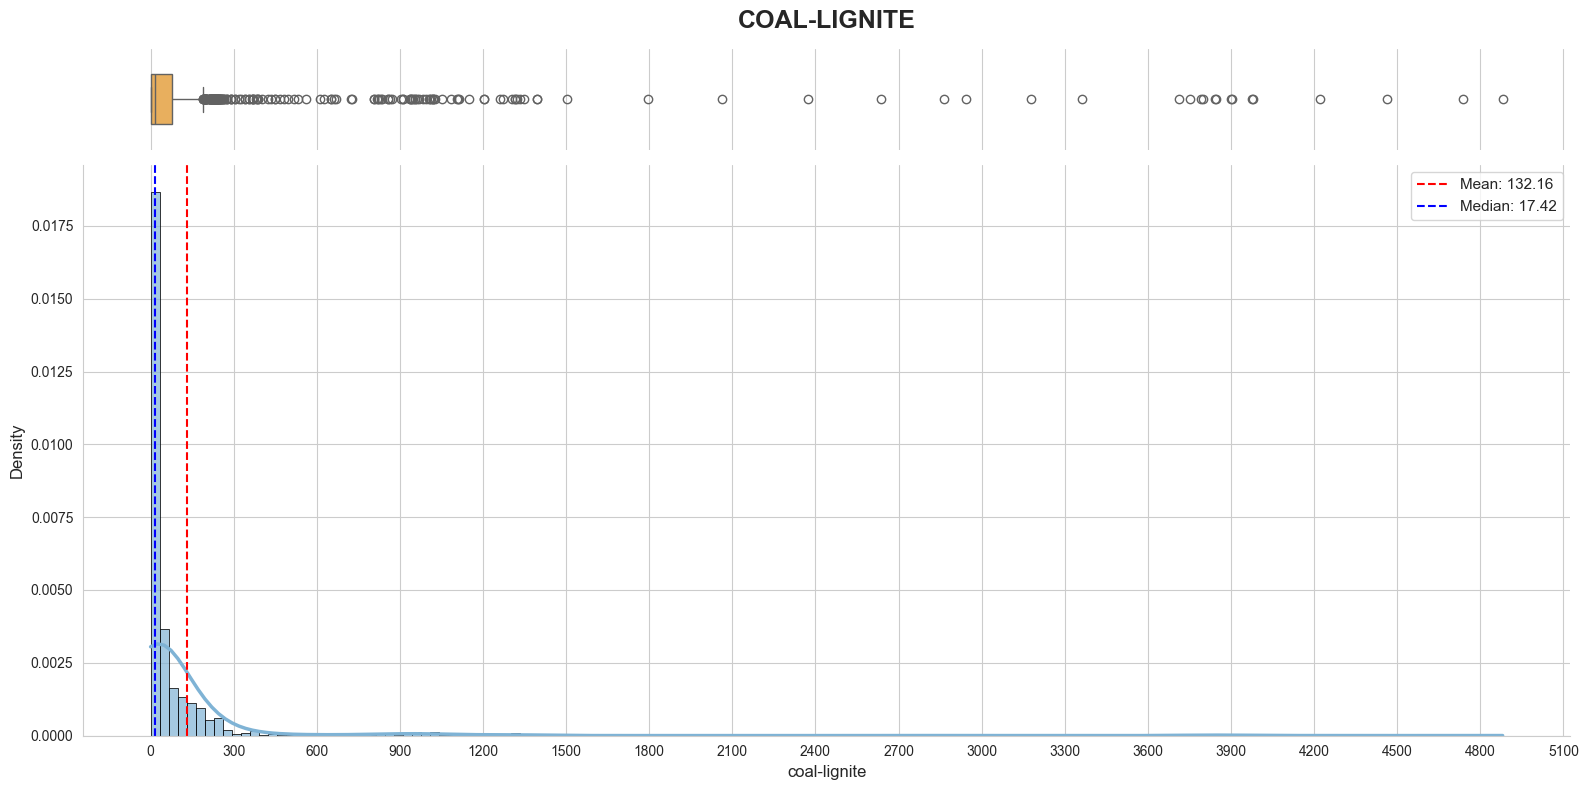

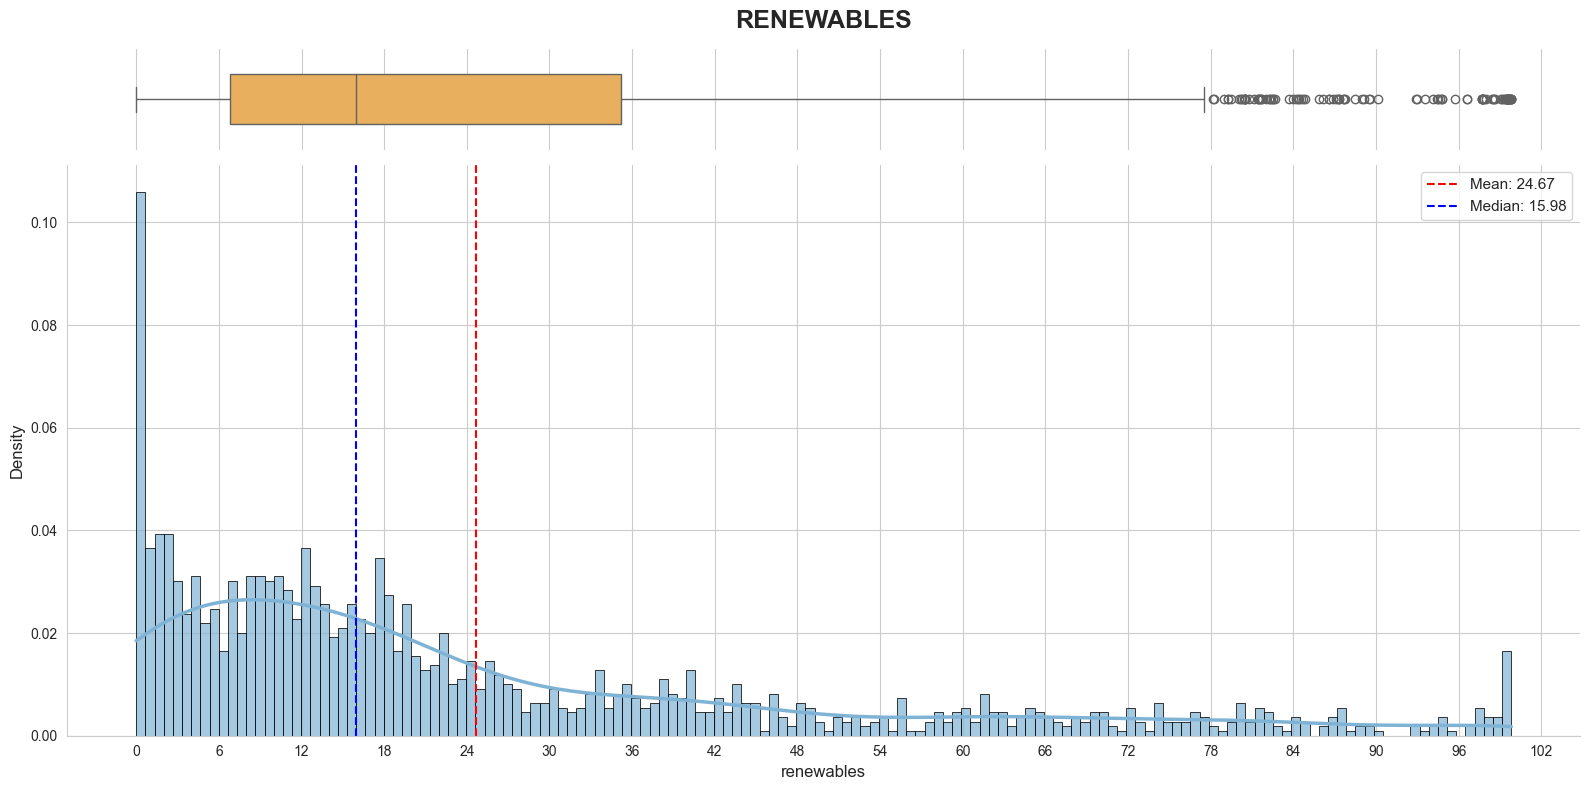

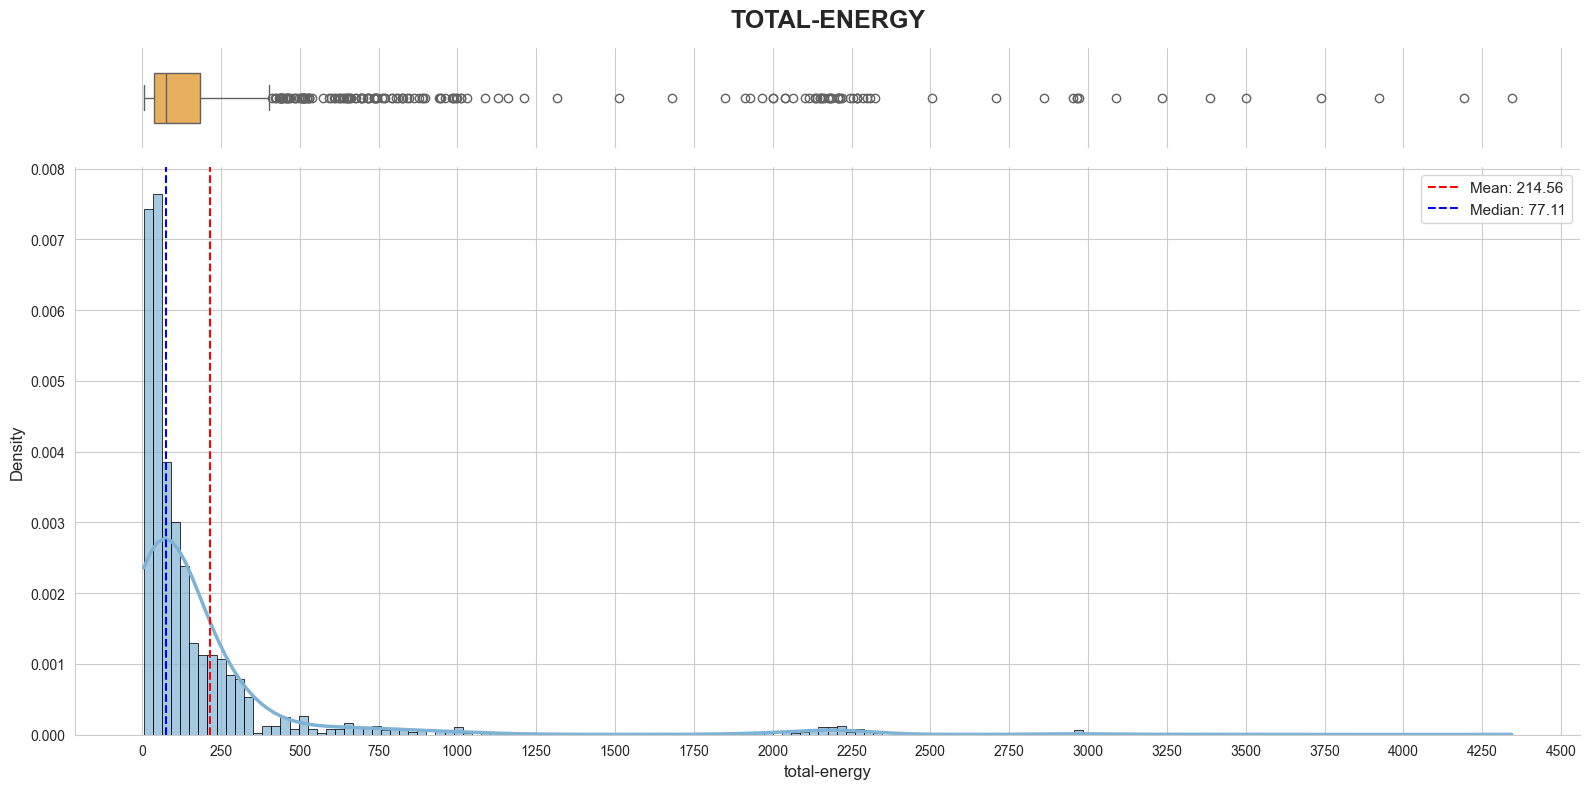

In [8]:
sns.set_style("whitegrid")
cols_to_plot = ['co2-emissions', 'coal-lignite', 'renewables', 'total-energy']

for col_name in cols_to_plot:
    fig, (ax_box, ax_hist) = plt.subplots(nrows=2, ncols=1, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(16, 8))
    
    sns.boxplot(data=df, x=col_name, ax=ax_box, color='#ffb347', width=0.5)
    
    ax_box.set_title(col_name.upper(), fontsize=18, pad=15, fontweight='bold')
    ax_box.set_xlabel('') 
    
    sns.histplot(data=df, x=col_name, bins=150, kde=True, stat='density', 
                 color='#7fb3d5', edgecolor='black', alpha=0.7, ax=ax_hist,
                 line_kws={'color': '#000080', 'linewidth': 2.5})
    
    mean_val = df[col_name].mean()
    median_val = df[col_name].median()
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax_hist.axvline(median_val, color='blue', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    

    ax_hist.xaxis.set_major_locator(ticker.MaxNLocator(20))
    ax_hist.set_xlabel(col_name, fontsize=12)
    ax_hist.set_ylabel('Density', fontsize=12)
    ax_hist.legend(loc='upper right', fontsize=11)
    

    for ax in [ax_box, ax_hist]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax_box.spines['left'].set_visible(False)
    ax_box.spines['bottom'].set_visible(False)
    ax_box.set_yticks([]) 

    plt.tight_layout()
    plt.show()

- Nhìn tổng thể, cả bốn đặc trưng đều có chung một hình thái phân phối là dữ liệu bị lệch phải rất mạnh

## 2. LÀM SẠCH VÀ CHUẨN HÓA DỮ LIỆU

### 2.1 Làm sạch dữ liệu 
#### a. Xử lý NaN


In [10]:
df_with_nan = df[df.isna().any(axis=1)]


print("Một số mẫu dữ liệu chứa giá trị NaN:")
display(df_with_nan)
def get_missing_columns(group):
    missing_cols = group.columns[group.isna().any()].tolist()
    return ", ".join(missing_cols)


missing_summary = df_with_nan.groupby('Country')['Year'].agg(
    Năm_Bắt_Đầu_Thiếu='min',
    Năm_Kết_Thúc_Thiếu='max',
    Số_Lượng_Năm_Thiếu='count'
)
missing_columns_info = df_with_nan.groupby('Country').apply(get_missing_columns)
missing_columns_info.name = 'Các_Loại_Năng_Lượng_Bị_Thiếu'


final_summary = missing_summary.join(missing_columns_info)


print("\nThống kê chi tiết thiếu dữ liệu theo từng quốc gia:")
display(final_summary)


Một số mẫu dữ liệu chứa giá trị NaN:


,Country,Year,co2-emissions,coal-lignite,electricity,natural-gas,oil-products,renewables,renewables-wind-solar,total-energy
735,Kuwait,1990,32.276646,NaN,14.449000,6.991713,4.728768,0.0,0.0,14.008281
736,Kuwait,1991,14.159879,NaN,8.200000,0.934218,4.046000,0.0,0.0,5.365732
737,Kuwait,1992,29.218818,NaN,13.100000,5.244336,3.814000,0.0,0.0,11.168121
738,Kuwait,1993,41.412564,NaN,13.800000,9.779819,5.196854,0.0,0.0,18.503931
739,Kuwait,1994,46.063431,NaN,18.200000,10.157003,6.301782,0.0,0.0,20.563000
...,...,...,...,...,...,...,...,...,...,...
1115,Qatar,2020,83.716713,NaN,43.089429,54.983413,8.235634,NaN,NaN,47.454177
1116,Qatar,2021,85.418330,NaN,45.404091,56.484472,8.506351,NaN,NaN,49.118396
1117,Qatar,2022,90.490540,NaN,48.199426,55.262505,9.304758,NaN,NaN,50.551556
1118,Qatar,2023,94.936942,NaN,52.593095,57.694707,9.970719,NaN,NaN,53.221001



Thống kê chi tiết thiếu dữ liệu theo từng quốc gia:


C:\Users\tranh\AppData\Local\Temp\ipykernel_3548\291488438.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_columns_info = df_with_nan.groupby('Country').apply(get_missing_columns)


,Năm_Bắt_Đầu_Thiếu,Năm_Kết_Thúc_Thiếu,Số_Lượng_Năm_Thiếu,Các_Loại_Năng_Lượng_Bị_Thiếu
Country,,,,
Kuwait,1990,2024,35,coal-lignite
Qatar,1990,2024,35,"coal-lignite, renewables, renewables-wind-solar"


### Nhận xét
- Nhóm nghiên cứu thấy giá trị NaN này thuộc hoàn toàn về 2 nước Kuwait và Qatar từ 1990 - 2024 (do nhà cung cấp không thu thập được dữ liệu từ 2 nước này) 
- Từ đó, nhóm kết luận rằng rằng các giá trị dữ liệu thiếu trong trường hợp này không phải do lỗi thu thập dữ liệu, mà xuất phát từ bản chất thực tế của hệ thống năng lượng tại các quốc gia này. Vì mức tiêu thụ các loại năng lượng này gần như bằng 0, các giá trị NaN có thể được thay thế bằng 0 trong quá trình tiền xử lý dữ liệu để phản ánh đúng thực tế tiêu thụ năng lượng.

#### Thay thế các giá trị NaN bằng 0

In [11]:
# Sao chép dữ liệu
dulieu_xuly_nan = df.copy()


# Các cột cần xử lý NaN
cols_to_fill_zero = ['coal-lignite', 'renewables', 'renewables-wind-solar']


# Thay NaN bằng 0
dulieu_xuly_nan[cols_to_fill_zero] = dulieu_xuly_nan[cols_to_fill_zero].fillna(0)

print("Số lượng NaN của các cột sau khi xử lý:")
print(dulieu_xuly_nan[cols_to_fill_zero].isna().sum())




Số lượng NaN của các cột sau khi xử lý:
coal-lignite             0
renewables               0
renewables-wind-solar    0
dtype: int64


#### Phân phối các biến sau khi xử lý NaN

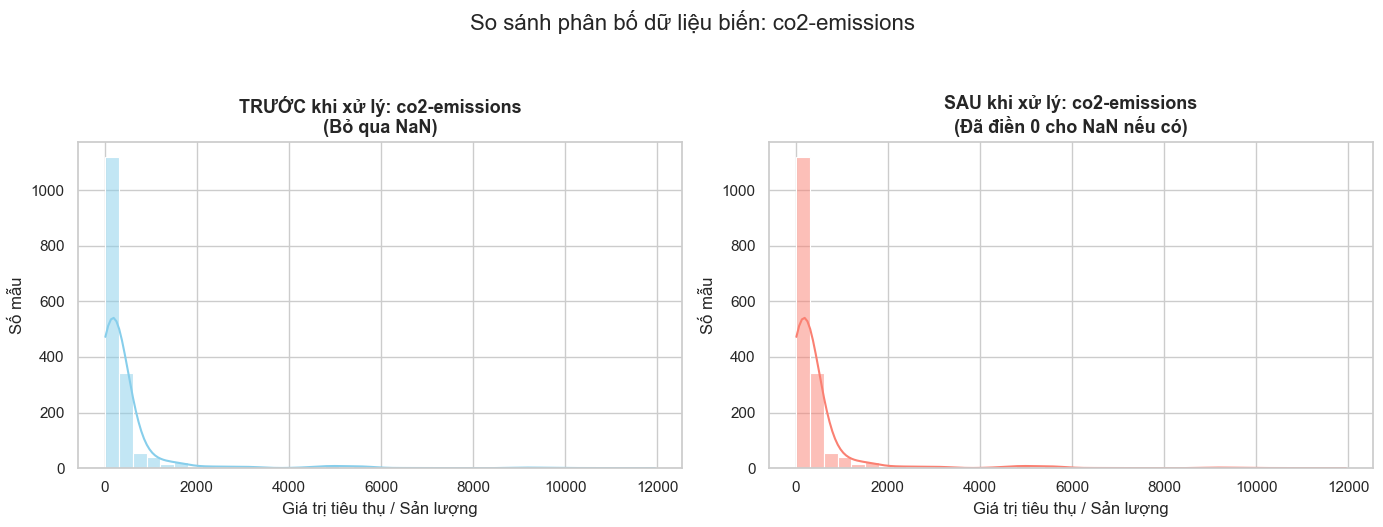

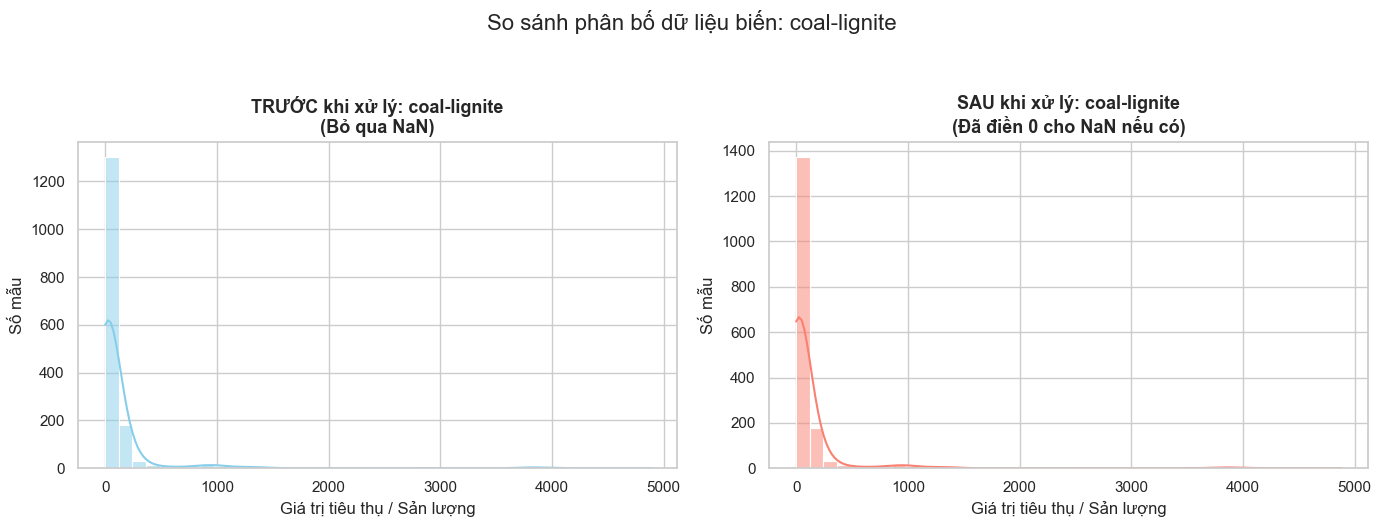

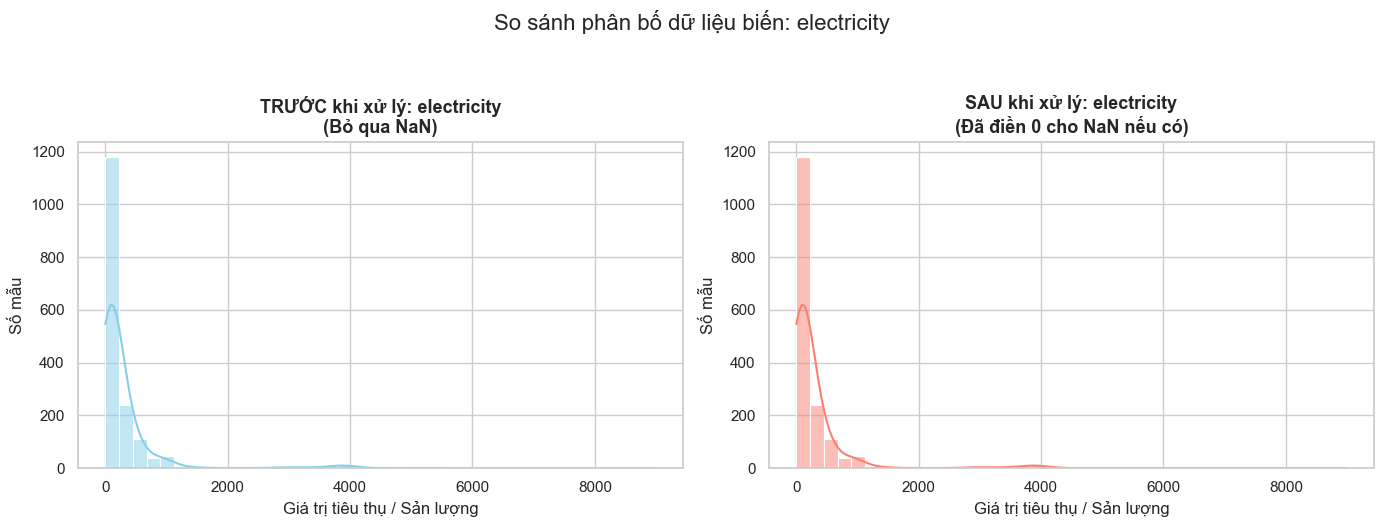

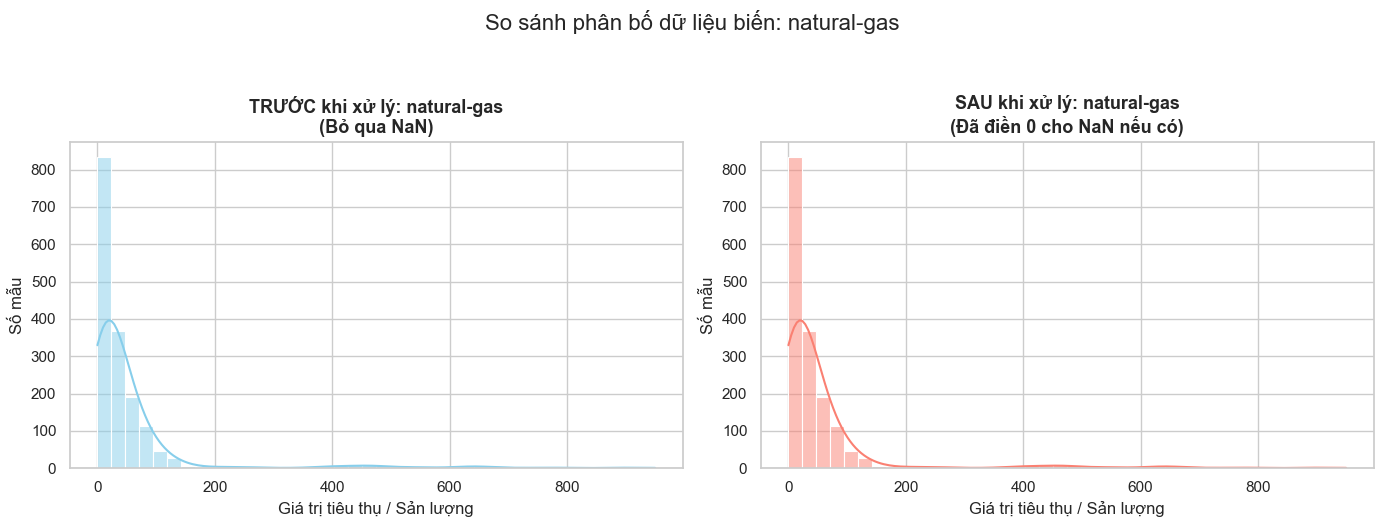

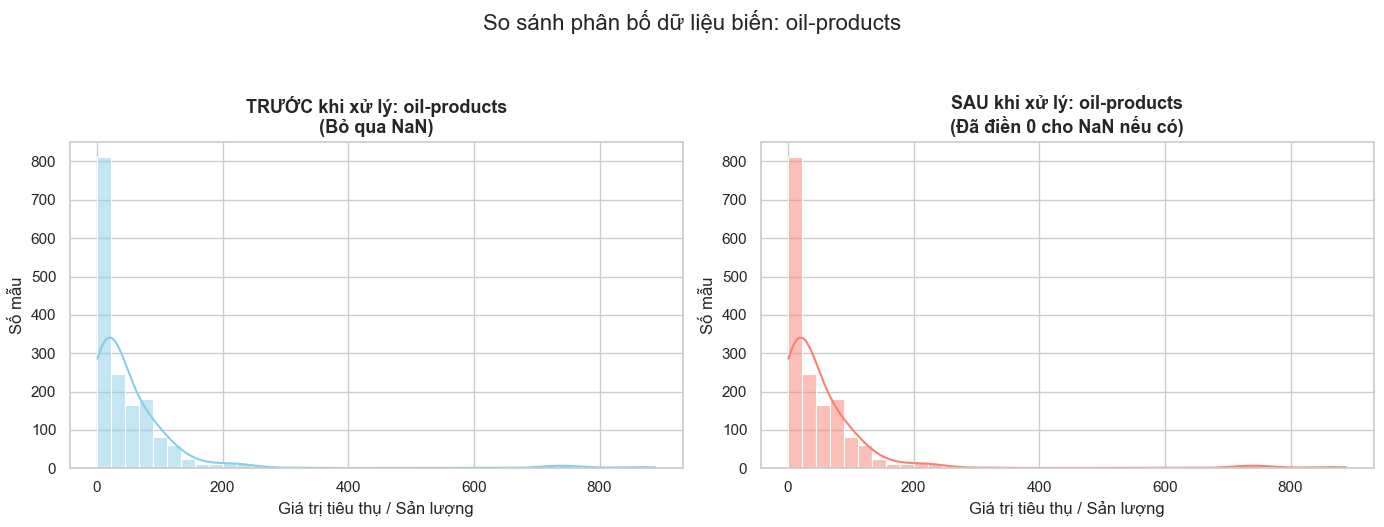

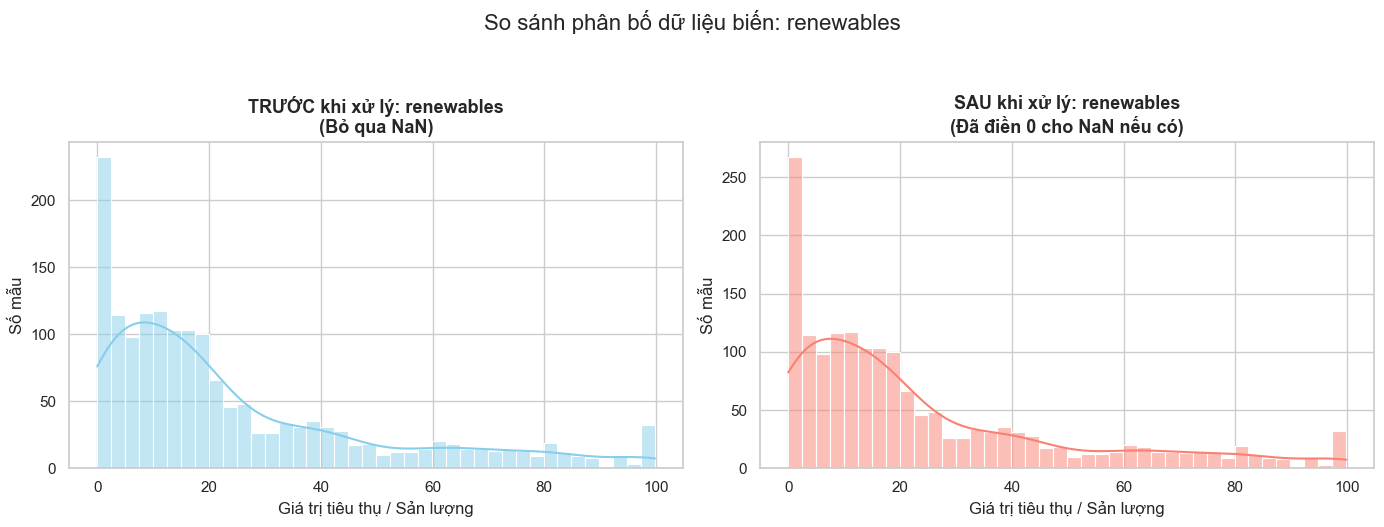

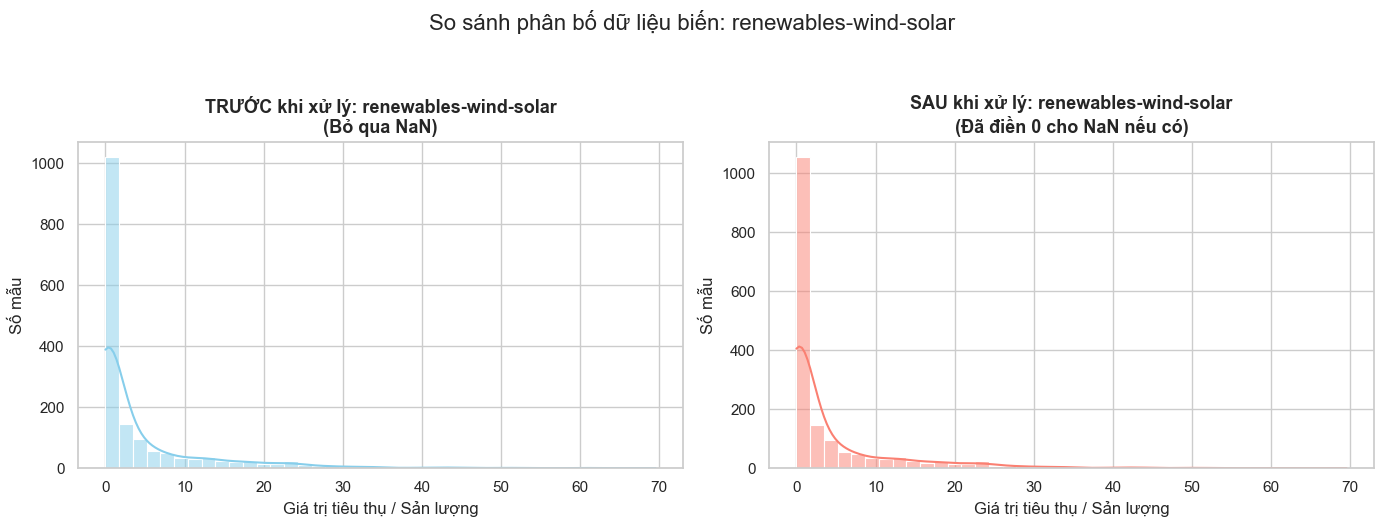

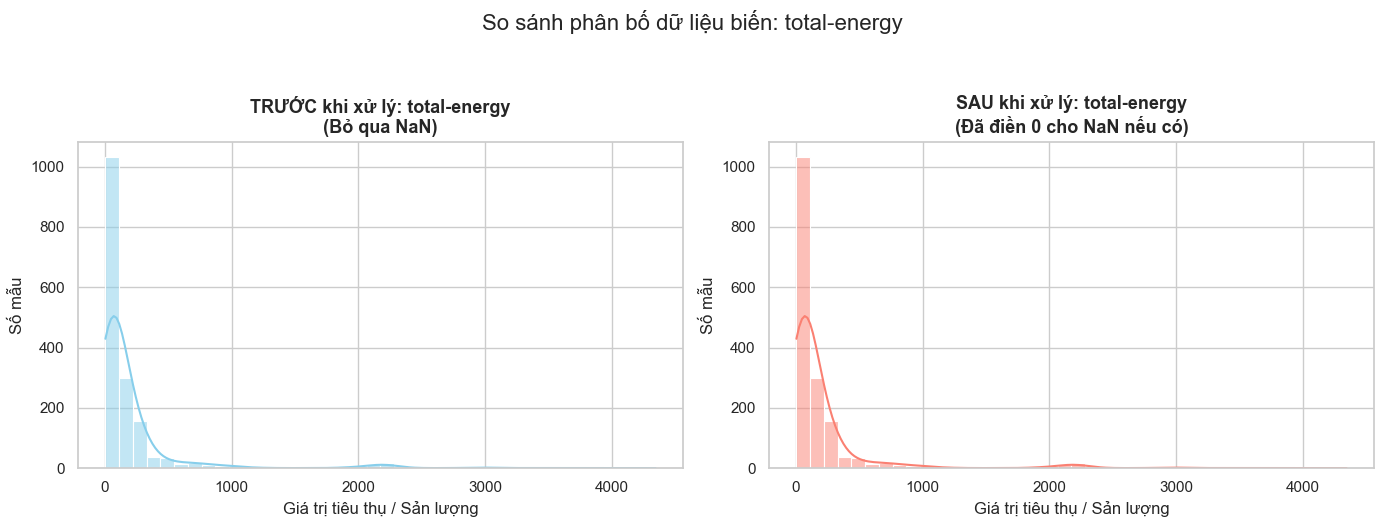

In [12]:
# df là dữ liệu trước khi xử lý (đã có sẵn)
# dulieu_xuly_nan là dữ liệu sau khi xử lý NaN


energy_cols = [
    'co2-emissions', 'coal-lignite', 'electricity',
    'natural-gas', 'oil-products', 'renewables',
    'renewables-wind-solar', 'total-energy'
]


sns.set_theme(style="whitegrid")


for col in energy_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    sns.histplot(df[col].dropna(), bins=40, kde=True, color='skyblue', ax=axes[0])
    axes[0].set_title(f'TRƯỚC khi xử lý: {col}\n(Bỏ qua NaN)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Giá trị tiêu thụ / Sản lượng')
    axes[0].set_ylabel('Số mẫu')


    sns.histplot(dulieu_xuly_nan[col], bins=40, kde=True, color='salmon', ax=axes[1])
    axes[1].set_title(f'SAU khi xử lý: {col}\n(Đã điền 0 cho NaN nếu có)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Giá trị tiêu thụ / Sản lượng')
    axes[1].set_ylabel('Số mẫu')
   
    plt.suptitle(f'So sánh phân bố dữ liệu biến: {col}', fontsize=16, y=1.05)
   
    plt.tight_layout()
    plt.show()


### Nhận xét
- Thay thế dữ liệu bị thiếu bằng 0 làm tăng số giá trị 0 ở một số biến (coal-lignite, renewables).
- Phân bố dữ liệu gần như giữ nguyên, các biến vẫn lệch phải.
- Thay NaN bằng 0 không làm thay đổi đáng kể phân bố dữ liệu và phù hợp với thực tế rằng một số quốc gia không sử dụng hoặc không sản xuất một số loại năng lượng

#### b. Xử lý Outlier

- Xử lý outlier được nhóm nghiên cứu lựa chọn phương pháp Capping dựa trên IQR, vì trong tập dữ liệu, một số biến (C02 emissions, total-energy, oil-products,..) có sự chênh lệch rất lớn giữa các quốc gia nên có nhiều giá trị outlier lớn, làm cho dữ liệu lệch phải nặng
- Nếu sử dụng Winsorization thông thường với 1.5IQR thì nhiều giá trị tiêu thụ lớn nhưng hợp lý sẽ bị cắt đi, làm mất thông tin quan trọng về lượng tiêu thụ năng lượng của một số nước lớn.


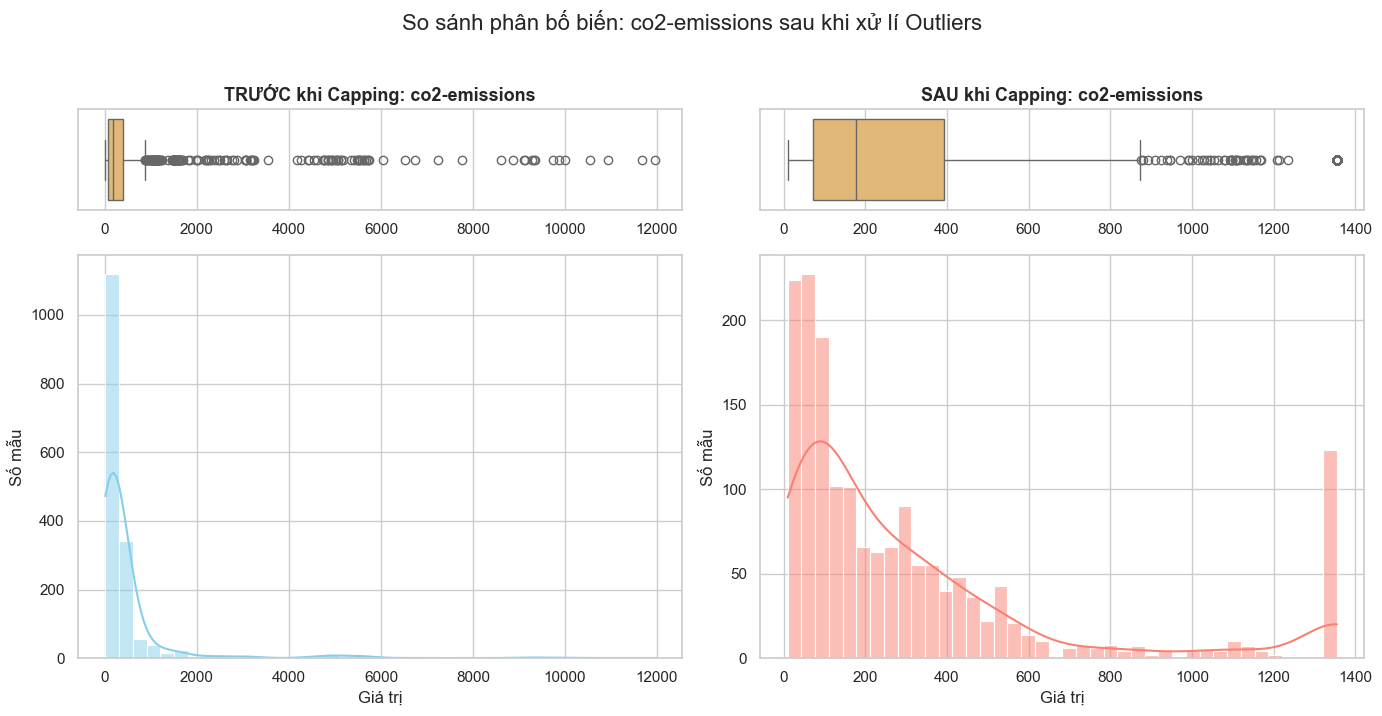

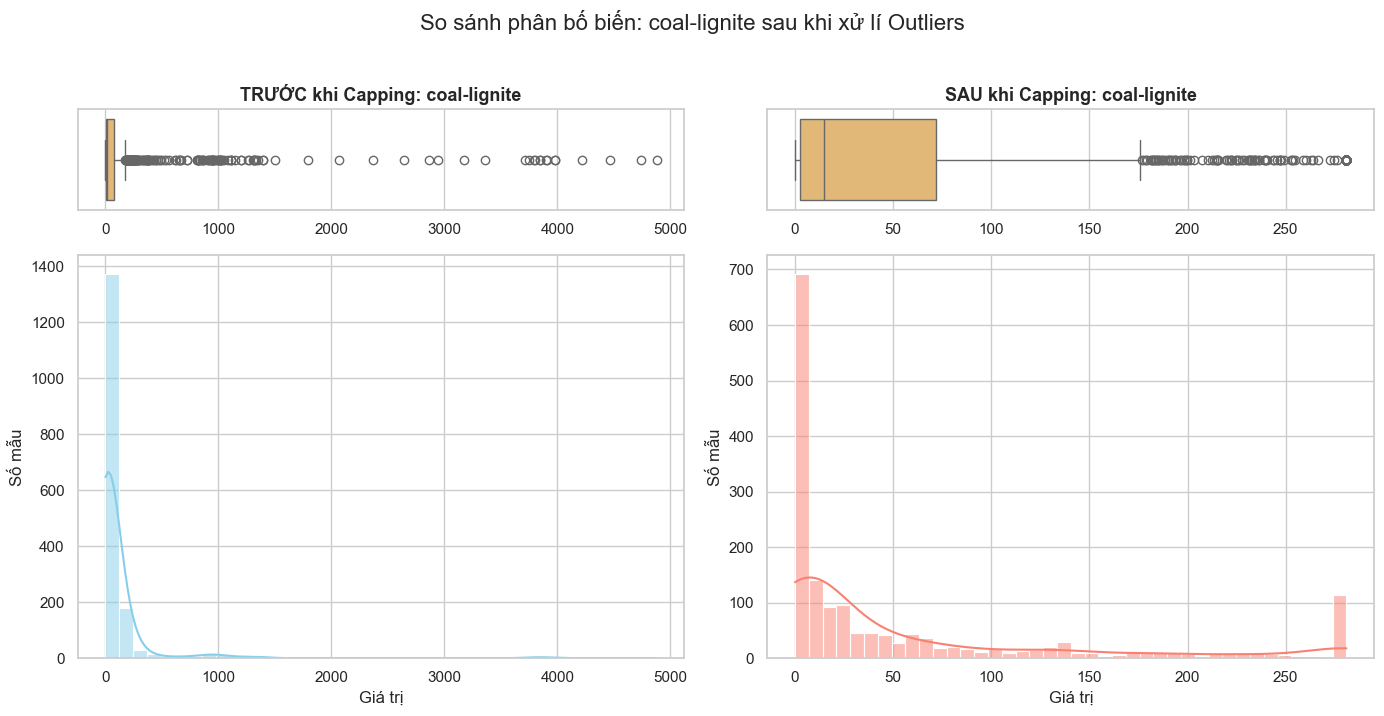

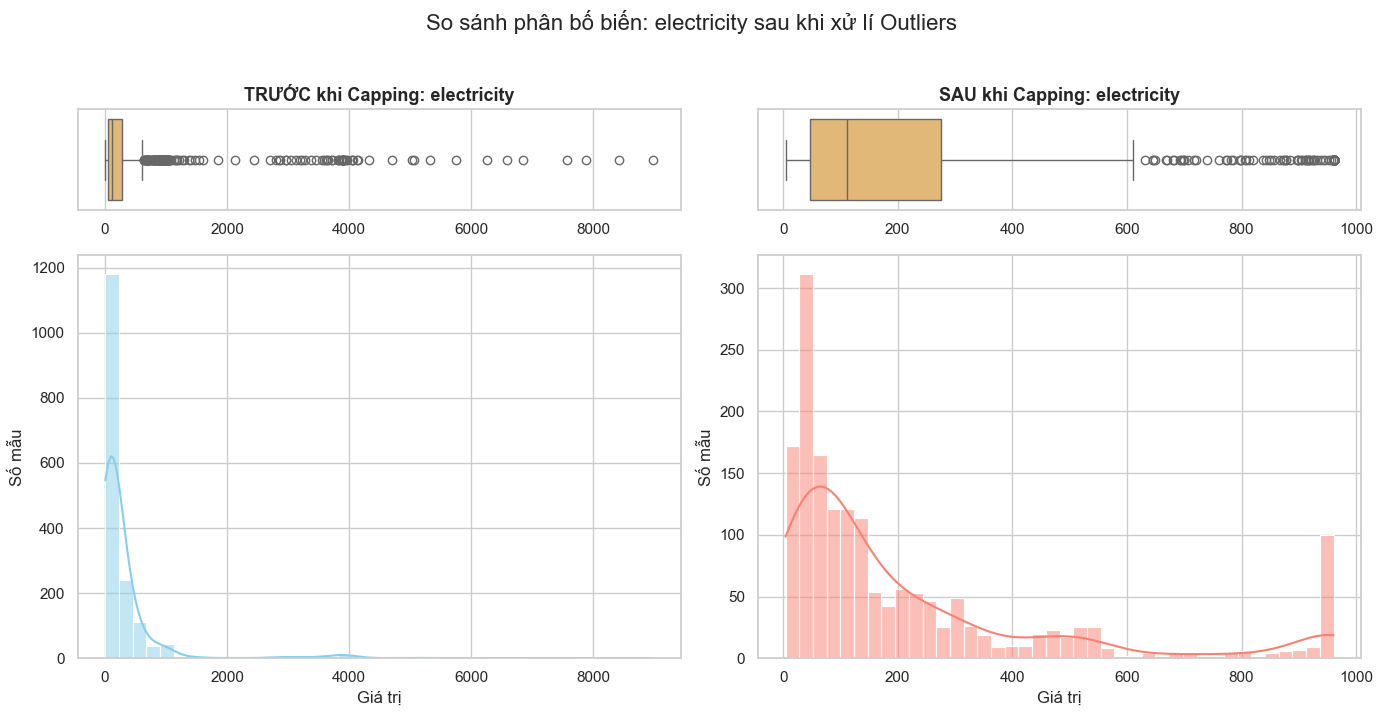

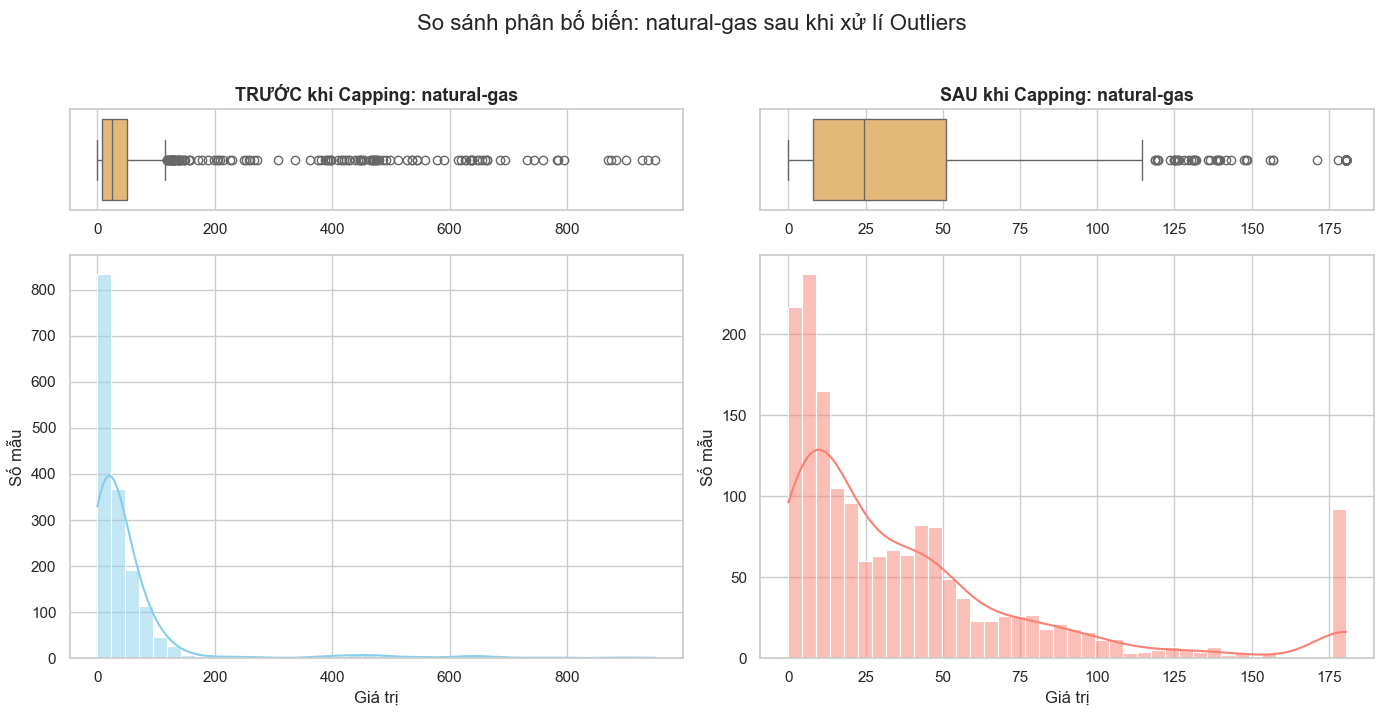

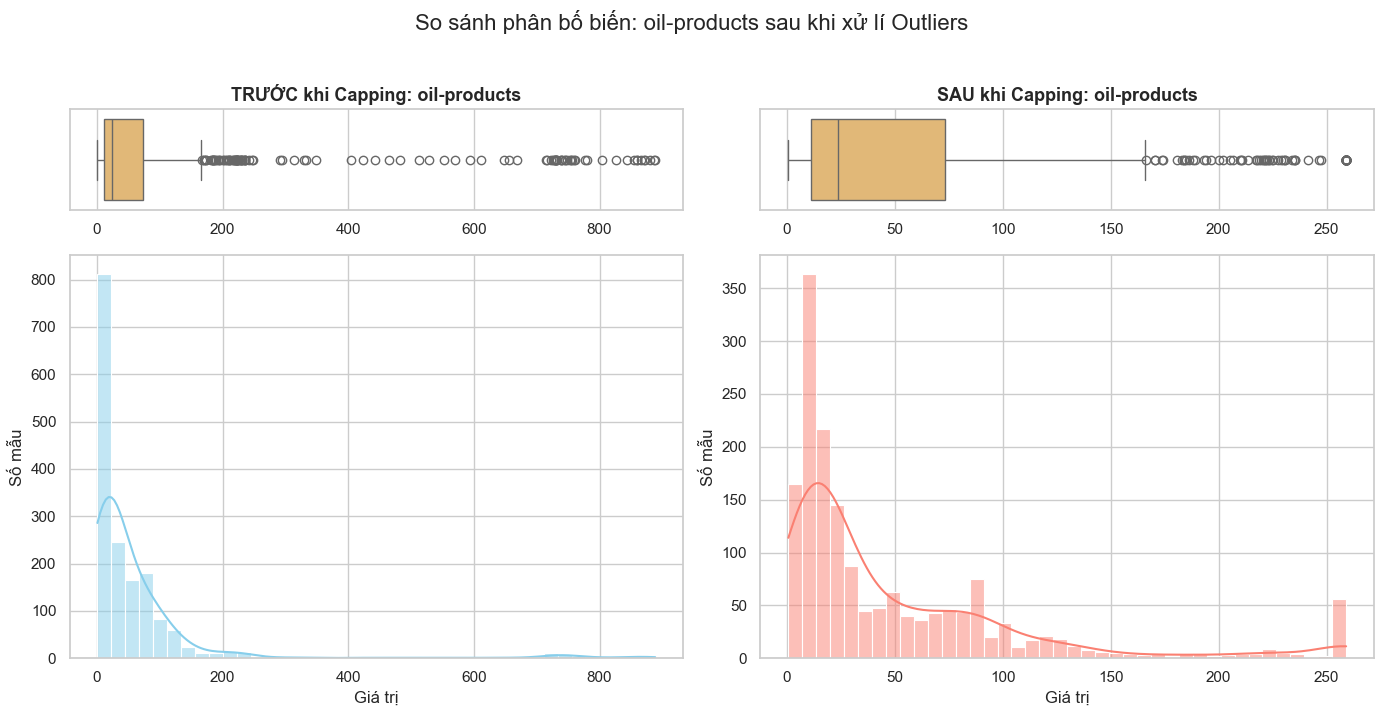

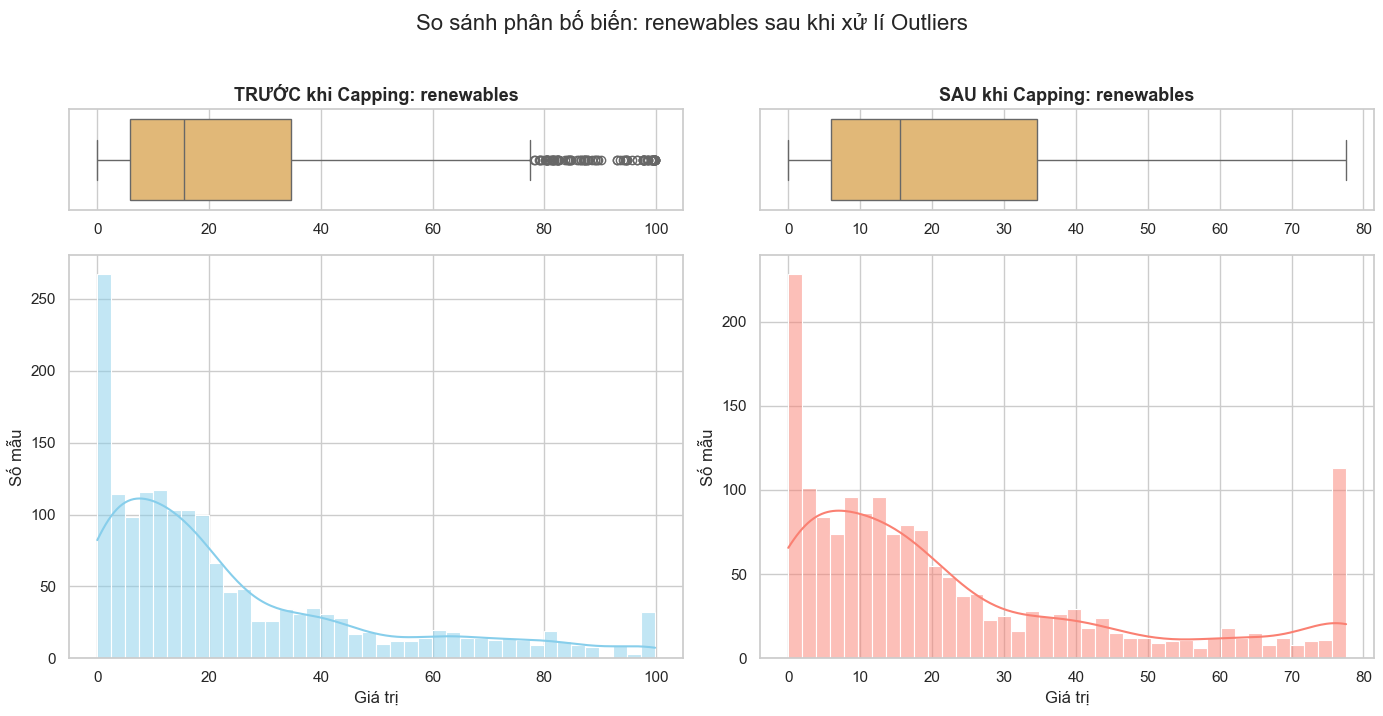

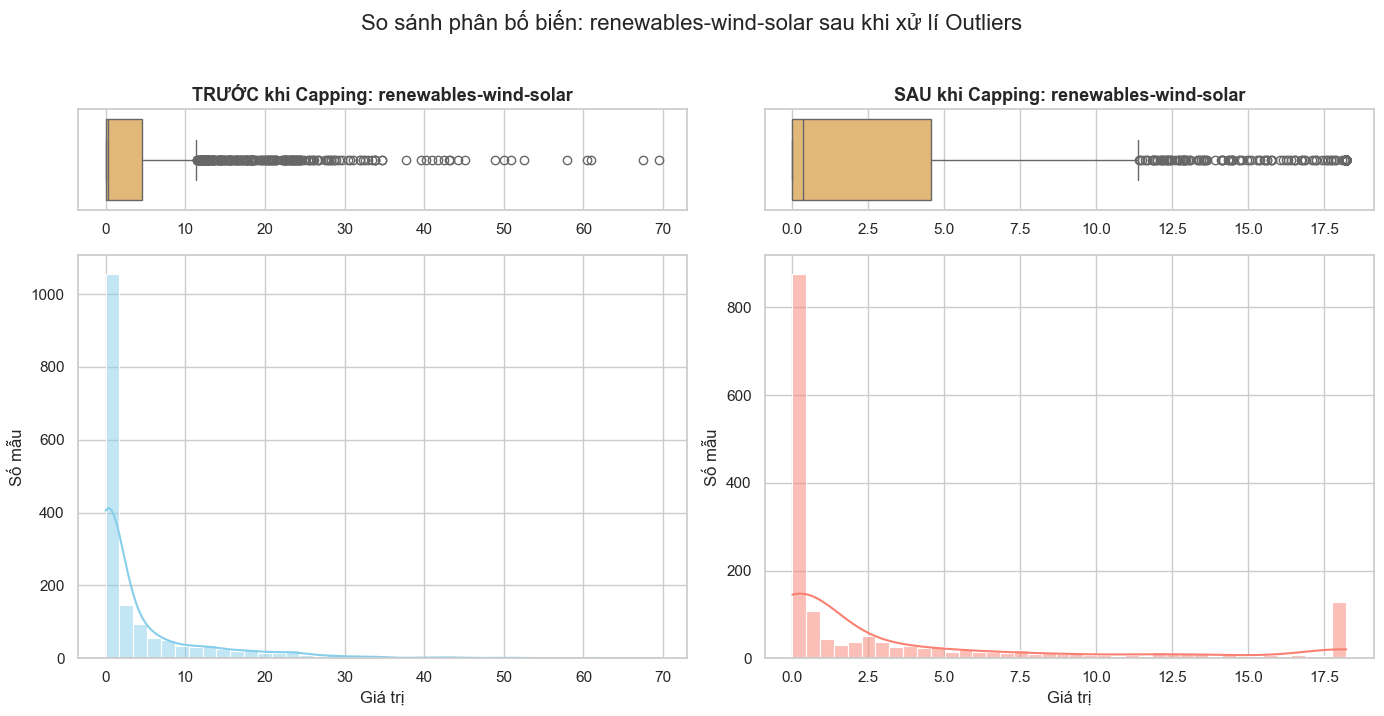

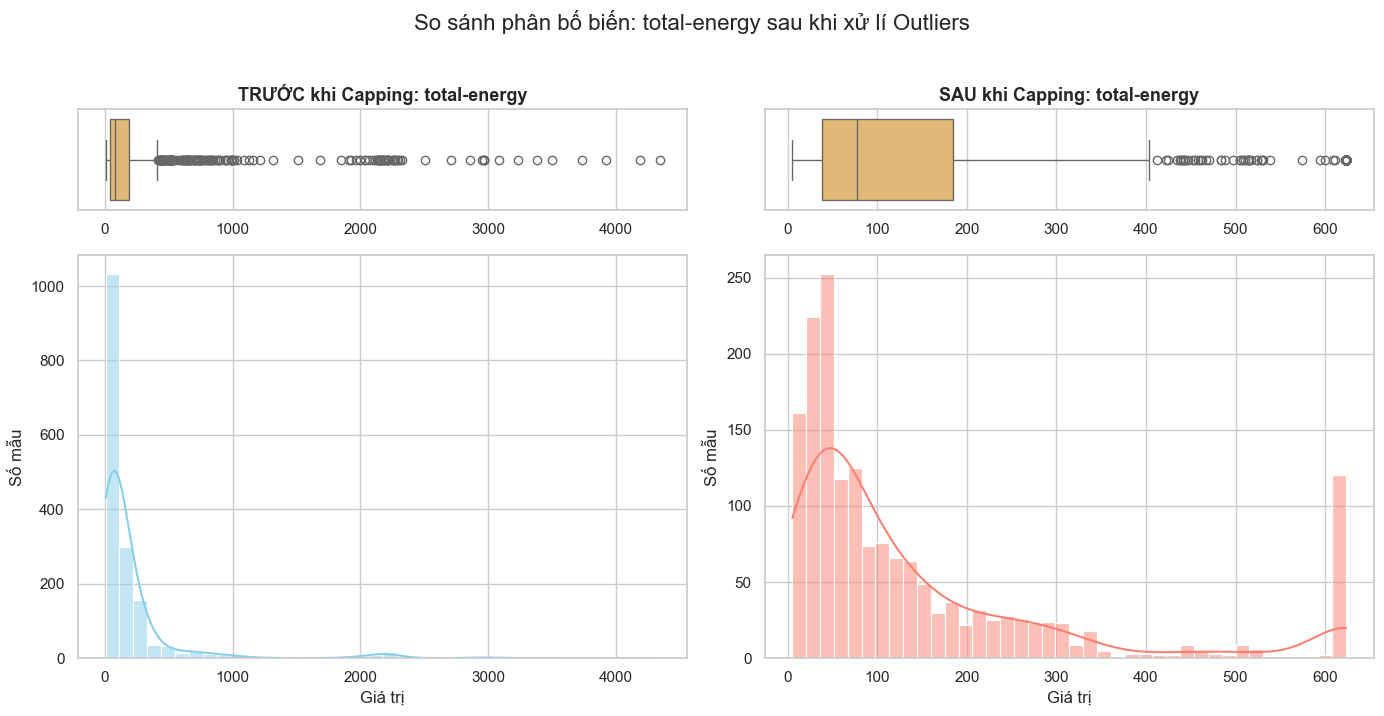

In [13]:
# Đọc dữ liệu gốc
dulieu_truocxuly_outlier = dulieu_xuly_nan.copy()


# Sao chép để xử lý
dulieu_xuly_outlier = dulieu_truocxuly_outlier.copy()


energy_cols = [
    'co2-emissions', 'coal-lignite', 'electricity',
    'natural-gas', 'oil-products', 'renewables',
    'renewables-wind-solar', 'total-energy'
]


for col in energy_cols:
    Q1 = dulieu_xuly_outlier[col].quantile(0.25)
    Q3 = dulieu_xuly_outlier[col].quantile(0.75)
    IQR = Q3 - Q1


    if col == 'renewables':
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    else:
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR


    dulieu_xuly_outlier[col] = dulieu_xuly_outlier[col].clip(lower=lower_bound, upper=upper_bound)

sns.set_theme(style="whitegrid")


for col in energy_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), gridspec_kw={'height_ratios': [0.2, 0.8]})


    # BEFORE
    sns.boxplot(x=dulieu_truocxuly_outlier[col], ax=axes[0, 0], color='#f2bc66')
    axes[0, 0].set_title(f'TRƯỚC khi Capping: {col}', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('')


    sns.histplot(dulieu_truocxuly_outlier[col], bins=40, kde=True, color='skyblue', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Giá trị')
    axes[1, 0].set_ylabel('Số mẫu')


    # AFTER
    sns.boxplot(x=dulieu_xuly_outlier[col], ax=axes[0, 1], color='#f2bc66')
    axes[0, 1].set_title(f'SAU khi Capping: {col}', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('')


    sns.histplot(dulieu_xuly_outlier[col], bins=40, kde=True, color='salmon', ax=axes[1, 1])
    axes[1, 1].set_xlabel('Giá trị')
    axes[1, 1].set_ylabel('Số mẫu')


    plt.suptitle(f'So sánh phân bố biến: {col} sau khi xử lí Outliers', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()



#### Nhận xét sau khi xử lý outliers
- Sau khi xử lý, phần lớn các biến vẫn giữ phân bố lệch phải, phản ánh sự khác biệt lớn giữa các quốc gia về tiêu thụ năng lượng và phát thải. Việc xử lý outliers giúp giảm ảnh hưởng của các giá trị quá lớn, khiến dữ liệu ổn định và dễ phân tích hơn.
-  Khi sử dụng ngưỡng 3IQR thì chỉ những giá trị nằm rất xa mới bị giới hạn. Các điểm nằm trong khoảng 1.5IQR đến 3IQR vẫn còn nhưng giá trị ngoại lai , từ đó sử dụng phương pháp chuẩn hóa RobustScaler, vì phương pháp này dựa trên median và IQR nên ít bị ảnh hưởng bởi các giá trị ngoại lại còn lại.

### 2.2 Chuẩn hóa dữ liệu


- Sử dụng chuẩn hóa mạnh (RobustScaler) vì dữ liệu năng lượng có outlier (giá trị lớn/ nhỏ) giữa các quốc gia
- RobustScaler chuẩn hóa dữ liệu bằng median và IQR  thay vì mean và độ lệch chuẩn, nên ít bị ảnh hưởng bởi outlier và giúp dữ liệu ổn định hơn cho mô hình học máy.

In [14]:

energy_cols = [
    'co2-emissions', 'coal-lignite', 'electricity', 
    'natural-gas', 'oil-products', 'renewables', 
    'renewables-wind-solar', 'total-energy'
]

scaler = RobustScaler()

bien_da_chuanhoa = dulieu_xuly_outlier.copy()

bien_da_chuanhoa[energy_cols] = scaler.fit_transform(bien_da_chuanhoa[energy_cols])

print("Đã chuẩn hóa xong 8 cột bằng RobustScaler và lưu vào biến 'bien_da_chuanhoa'!")

Đã chuẩn hóa xong 8 cột bằng RobustScaler và lưu vào biến 'bien_da_chuanhoa'!


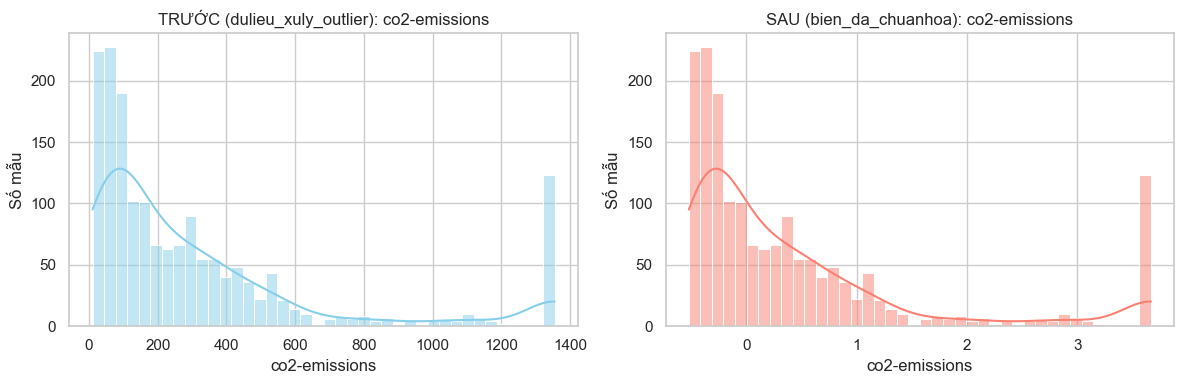

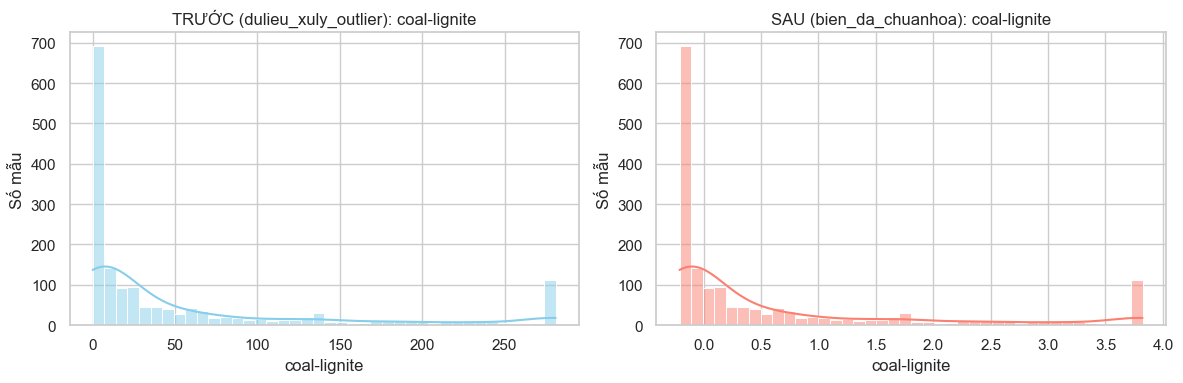

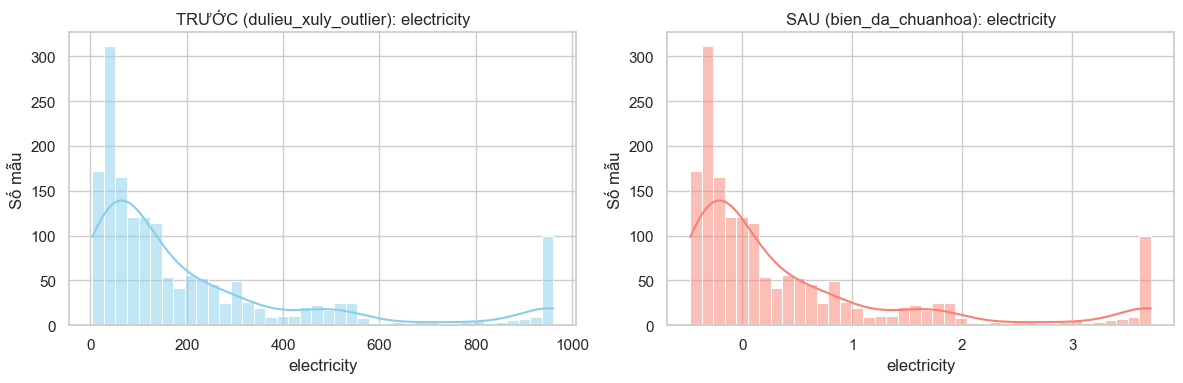

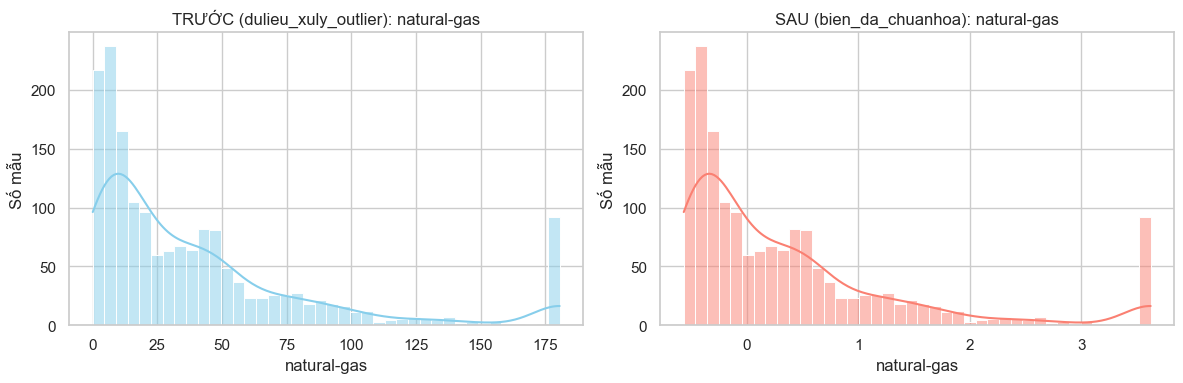

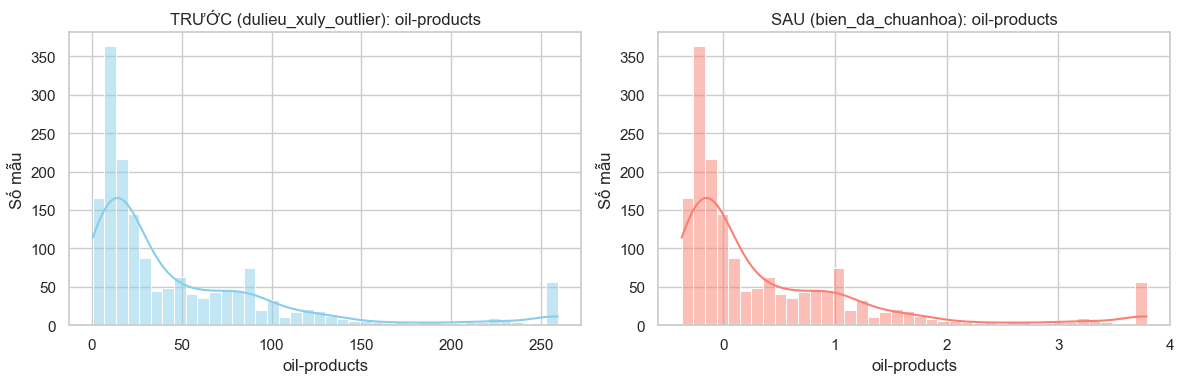

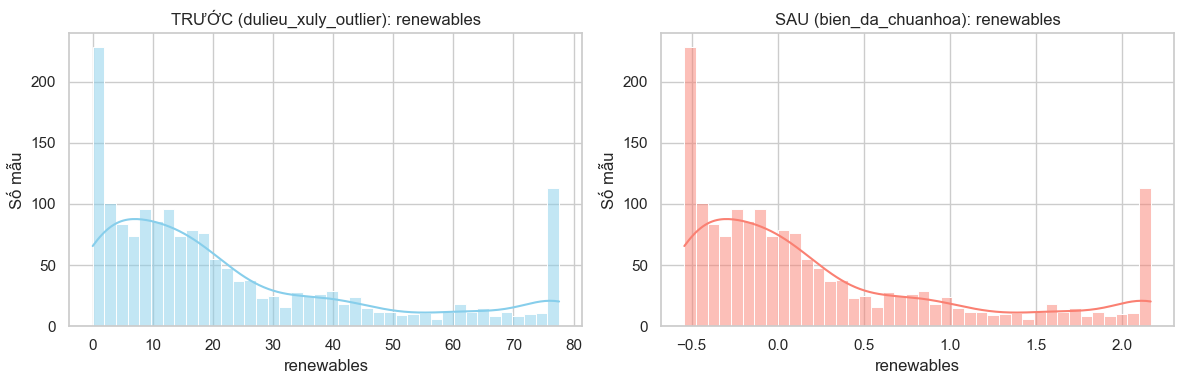

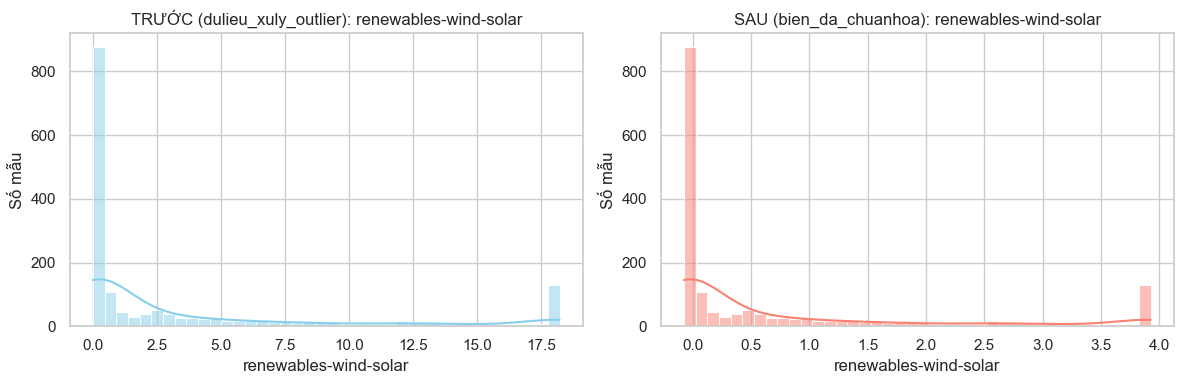

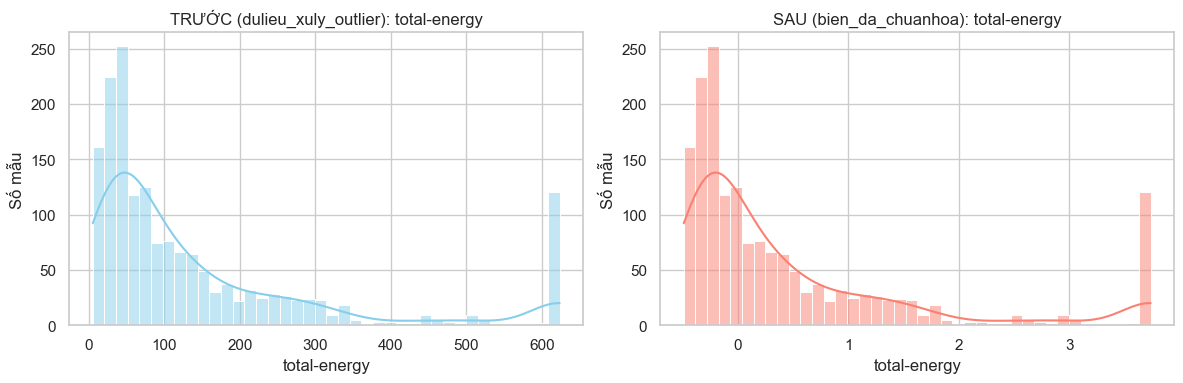

In [15]:
energy_cols = [
    'co2-emissions', 'coal-lignite', 'electricity', 
    'natural-gas', 'oil-products', 'renewables', 
    'renewables-wind-solar', 'total-energy'
]

sns.set_theme(style="whitegrid")

for col in energy_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(dulieu_xuly_outlier[col], bins=40, kde=True, color='skyblue', ax=axes[0])
    axes[0].set_title(f'TRƯỚC (dulieu_xuly_outlier): {col}')
    axes[0].set_ylabel('Số mẫu')
    
    sns.histplot(bien_da_chuanhoa[col], bins=40, kde=True, color='salmon', ax=axes[1])
    axes[1].set_title(f'SAU (bien_da_chuanhoa): {col}')
    axes[1].set_ylabel('Số mẫu')
    
    plt.tight_layout()
    plt.show()

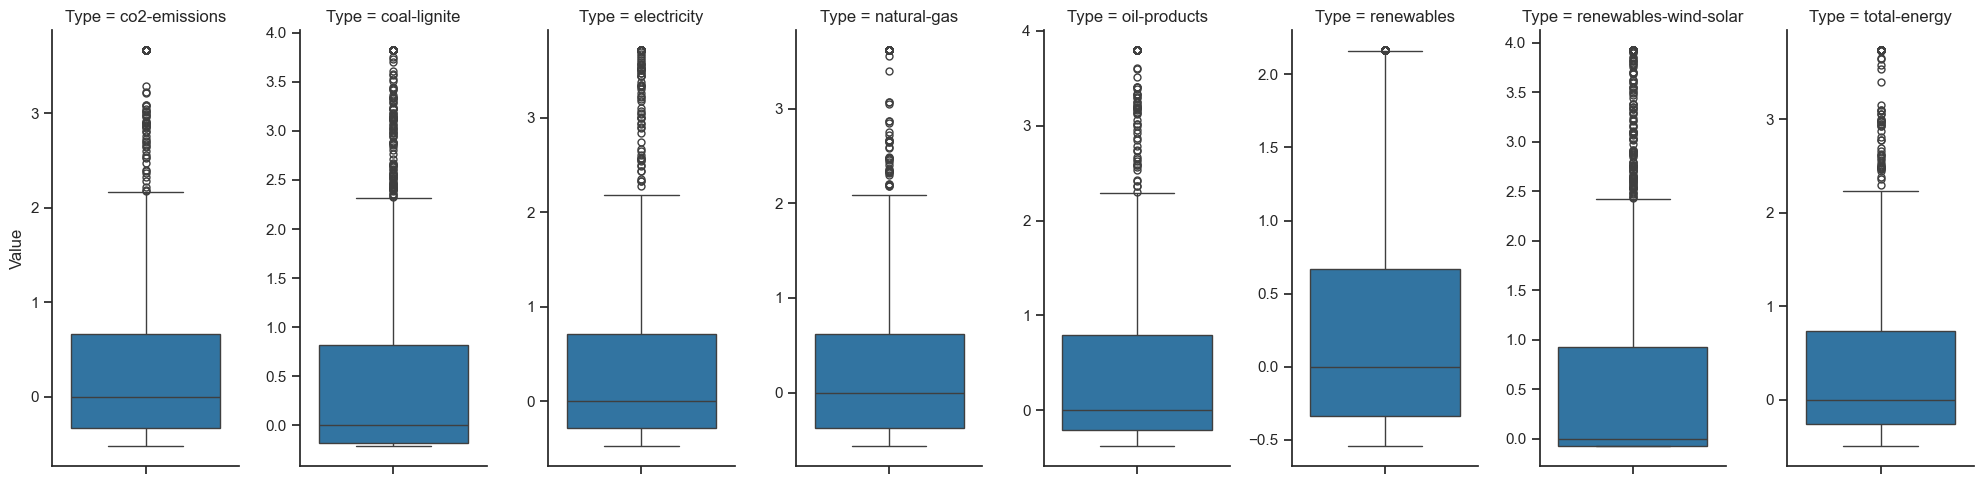

In [16]:
energy_cols = [
    'co2-emissions', 'coal-lignite', 'electricity', 
    'natural-gas', 'oil-products', 'renewables', 
    'renewables-wind-solar', 'total-energy'
]

# Chuyển đổi dữ liệu sang dạng dài
du_lieu_dang_dai = bien_da_chuanhoa.melt(value_vars=energy_cols, var_name='Type', value_name='Value')

# Vẽ biểu đồ
sns.set_theme(style="ticks") 

g = sns.catplot(
    data=du_lieu_dang_dai,
    y='Value',
    col='Type',    
    kind='box',
    sharex=False,
    sharey=False,
    height=5,
    aspect=0.5,
    legend=False,
    color='#1f77b4'
)

plt.show()

#### Nhận xét sau khi chuẩn hóa bằng RobustScaler
- Sau khi chuẩn hóa, các biến năng lượng vẫn lệch phải, cho thấy sự chênh lệch tiêu thụ giữa các quốc gia (đa số thấp, một số rất cao).
- Boxplot cho thấy vẫn còn một số giá trị nằm ngoài khoảng IQR, phản ánh sự chênh lệch tiêu thụ năng lượng giữa các quốc gia.Tuy nhiên, sau khi chuẩn hóa, dữ liệu đã được đưa về cùng thang đo quanh trung vị, giúp giảm ảnh hưởng của các giá trị quá lớn.

## 3. MÃ HÓA DỮ LIỆU CHO DỮ LIỆU DANH MỤC

In [17]:
le = LabelEncoder()

bien_da_chuanhoa['Country'] = le.fit_transform(bien_da_chuanhoa['Country'])

bien_da_chuanhoa.to_csv('clean_data.csv', index=False)
print(" Đã mã hóa xong và lưu vào 'clean_data.csv'!\n")

mapping_df = pd.DataFrame({
    'Mã số': range(len(le.classes_)),
    'Tên quốc gia': le.classes_
})

print("--- BẢNG ÁNH XẠ MÃ SỐ VÀ TÊN QUỐC GIA ---")
print(mapping_df.to_string(index=False))

 Đã mã hóa xong và lưu vào 'clean_data.csv'!

--- BẢNG ÁNH XẠ MÃ SỐ VÀ TÊN QUỐC GIA ---
 Mã số         Tên quốc gia
     0              Algeria
     1            Argentina
     2            Australia
     3           Azerbaijan
     4              Belgium
     5               Brazil
     6               Canada
     7                Chile
     8                China
     9             Colombia
    10              Czechia
    11              Denmark
    12                Egypt
    13               France
    14              Germany
    15                India
    16            Indonesia
    17                 Iran
    18                Italy
    19                Japan
    20           Kazakhstan
    21               Kuwait
    22             Malaysia
    23               Mexico
    24          Netherlands
    25          New Zealand
    26              Nigeria
    27               Norway
    28          Philippines
    29               Poland
    30             Portugal
    31          

## 4. XÂY DỰNG VÀ LỰA CHỌN ĐẶC TRƯNG

## 5. TRỰC QUAN HÓA MỐI QUAN HỆ GIỮA CÁC BIẾN DỮ LIỆU

## 6. KẾT LUẬN

## 7. TÀI LIỆU THAM KHẢO